# CI vs CD on Synthetic Correlation-Only Anomalies

Synthetic dataset where anomalies are pure correlation breaks
(circular shift preserving marginals and temporal structure).
CI should fail (no univariate signal), CD should succeed
(cross-channel dependencies are broken).

In [11]:
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from vus.metrics import get_metrics

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.synthetic_data import make_train, make_test, ANOM_SEGS, N_CHANNELS

In [12]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [13]:
def set_seed(s):
    np.random.seed(s)
    torch.manual_seed(s)
    if device == "cuda":
        torch.cuda.manual_seed_all(s)
    elif device == "mps":
        torch.mps.manual_seed(s)

default_seed = 2026
set_seed(default_seed)

In [14]:
window_size = 64
epochs = 30
batch_size = 128

In [15]:
X_train = make_train().astype(np.float32)
X_test, test_labels = make_test()
X_test = X_test.astype(np.float32)
test_labels = test_labels.astype(np.float32)

mu, std = X_train.mean(), X_train.std() + 1e-8
X_train = (X_train - mu) / std
X_test = (X_test - mu) / std

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Anomaly ratio: {test_labels.mean():.2%}")

Train: (20000, 9), Test: (10000, 9), Anomaly ratio: 15.00%


In [16]:
class Windows(Dataset):
    def __init__(self, data, labels=None, w=window_size, stride=1):
        self.data, self.labels, self.w, self.stride = data, labels, w, stride
        self.n = (len(data) - w) // stride + 1
        
    def __len__(self):
        return self.n
    
    def __getitem__(self, i):
        s = i * self.stride
        x = torch.from_numpy(self.data[s:s+self.w])
        return (x, torch.from_numpy(self.labels[s:s+self.w])) if self.labels is not None else (x,)
    

train_loader = DataLoader(Windows(X_train, stride=1), batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(Windows(X_test, test_labels, w=window_size, stride=window_size), batch_size=batch_size, shuffle=False, num_workers=0)

In [17]:
class LinearAECI(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.enc = nn.Linear(window_size, latent_dim)
        self.dec = nn.Linear(latent_dim, window_size)
    def forward(self, x):
        B, T, C = x.shape
        h = x.permute(0, 2, 1).reshape(B * C, T)
        r = self.dec(self.enc(h)).reshape(B, C, T).permute(0, 2, 1)
        return x, r
    

class LinearAECD(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        flat = window_size * N_CHANNELS
        self.enc = nn.Linear(flat, latent_dim)
        self.dec = nn.Linear(latent_dim, flat)
    def forward(self, x):
        B = x.size(0)
        r = self.dec(self.enc(x.reshape(B, -1))).reshape(B, window_size, N_CHANNELS)
        return x, r

In [18]:
def train(model):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(epochs):
        model.train()
        total = 0
        for (x,) in train_loader:
            x = x.to(device)
            opt.zero_grad()
            orig, recon = model(x)
            loss = F.mse_loss(recon, orig)
            loss.backward()
            opt.step()
            total += loss.item()
        if (ep + 1) % 10 == 0:
            print(f"  Epoch {ep+1}: {total/len(train_loader):.6f}")
    return model

def evaluate(model):
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for x, l in test_loader:
            orig, recon = model(x.to(device))
            scores.append(F.mse_loss(recon, orig, reduction='none').mean(2).cpu().numpy())
            labels.append(l.numpy())
    s, l = np.concatenate(scores).reshape(-1), np.concatenate(labels).reshape(-1)
    return roc_auc_score(l, s), average_precision_score(l, s)

In [ ]:
print("LinearAE-CI")
model_ci = LinearAECI(1024)
roc_ci, pr_ci = evaluate(train(model_ci))
print(f"AUC-ROC={roc_ci:.4f}  AUC-PR={pr_ci:.4f}")

print("\nLinearAE-CD")
model_cd = LinearAECD(1024)
roc_cd, pr_cd = evaluate(train(model_cd))
print(f"AUC-ROC={roc_cd:.4f}  AUC-PR={pr_cd:.4f}")

print(f"\nDelta (CD - CI): AUC-ROC={roc_cd-roc_ci:+.4f}  AUC-PR={pr_cd-pr_ci:+.4f}")

LinearAE-CI
  Epoch 10: 0.000000
  Epoch 20: 0.000000
  Epoch 30: 0.000000
AUC-ROC=0.5014  AUC-PR=0.1529

LinearAE-CD
  Epoch 10: 0.000077
  Epoch 20: 0.000425
  Epoch 30: 0.000274
AUC-ROC=0.9983  AUC-PR=0.9899

Delta (CD - CI): AUC-ROC=+0.4969  AUC-PR=+0.8370


In [10]:
def get_pointwise_scores(model, data, labels, window=window_size):
    ds = Windows(data, labels, w=window, stride=1)
    loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=0)
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, l in loader:
            orig, recon = model(x.to(device))
            score = F.mse_loss(recon, orig, reduction='none').mean(dim=2)
            all_scores.append(score.cpu().numpy())
            all_labels.append(l.numpy())
    scores = np.concatenate(all_scores)
    n_points = scores.shape[0] + window - 1
    score_sum = np.zeros(n_points)
    score_count = np.zeros(n_points)
    for i in range(scores.shape[0]):
        score_sum[i:i+window] += scores[i]
        score_count[i:i+window] += 1
    return score_sum / np.maximum(score_count, 1), labels[:n_points]

scores_ci, _ = get_pointwise_scores(model_ci, X_test, test_labels)
scores_cd, _ = get_pointwise_scores(model_cd, X_test, test_labels)

In [64]:
slidingWindow = 375  # VUS depends on the typical anomaly segment size in the dataset, 375 is the median

L = len(scores_ci)
y = test_labels[:L].astype(int)

vus_ci = get_metrics(scores_ci, y, metric='all', slidingWindow=slidingWindow)
vus_cd = get_metrics(scores_cd, y, metric='all', slidingWindow=slidingWindow)

print(f"{'metric':<12} {'CI':>8} {'CD':>8} {'delta':>8}")
for k in ['R_AUC_ROC', 'R_AUC_PR', 'VUS_ROC', 'VUS_PR']:
    print(f"{k:<12} {vus_ci[k]:>8.4f} {vus_cd[k]:>8.4f} {vus_cd[k]-vus_ci[k]:>+8.4f}")

metric             CI       CD    delta
R_AUC_ROC      0.6391   0.9888  +0.3497
R_AUC_PR       0.3063   0.9711  +0.6648
VUS_ROC        0.6104   1.0000  +0.3896
VUS_PR         0.2456   0.9998  +0.7542


VUS metrics artificially inflate the scores by rewarding the CI model for having detected the borders of the anomalous segments.

## Comparing CI vs CD reconstruction error on an anomaly segment

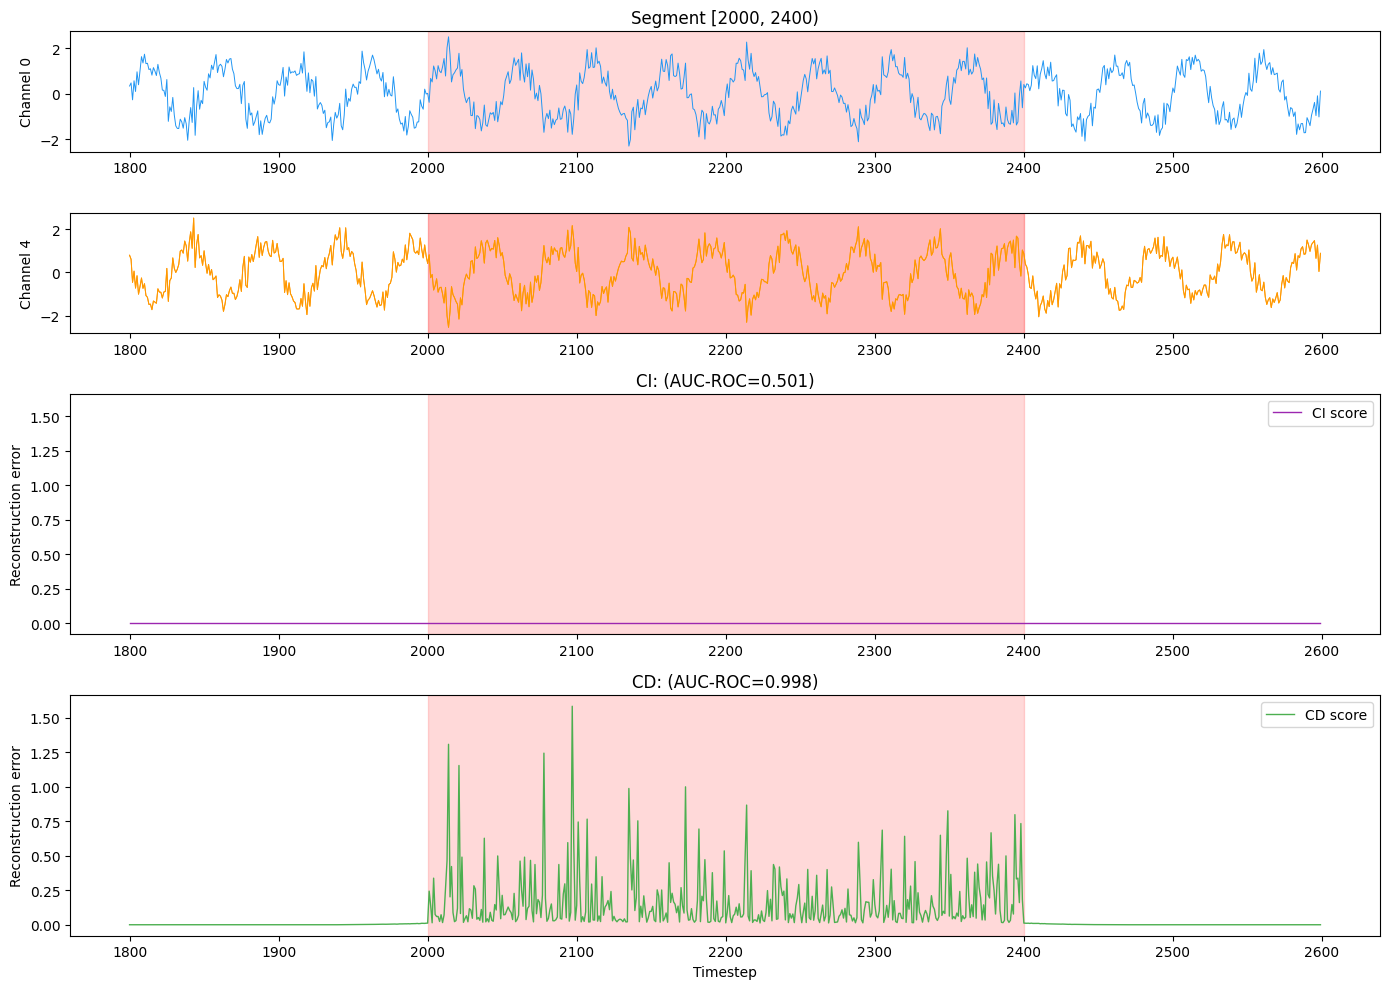

<Figure size 640x480 with 0 Axes>

In [65]:
seg_idx = 0
s, e = ANOM_SEGS[seg_idx]
margin = 200
view = slice(max(0, s - margin), min(len(scores_ci), e + margin))
t = np.arange(len(scores_ci))

fig, axes = plt.subplots(4, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1, 2, 2]})

axes[0].plot(t[view], X_test[view, 0], linewidth=0.7, color='#2196F3')
axes[0].axvspan(s, e, alpha=0.15, color='red')
axes[0].set_ylabel('Channel 0')
axes[0].set_title(f'Segment [{s}, {e})')

axes[1].plot(t[view], X_test[view, 4], linewidth=0.7, color='#FF9800')
axes[1].axvspan(s, e, alpha=0.15, color='red')
axes[1].set_ylabel('Channel 4')

axes[1].plot(t[view], X_test[view, 4], linewidth=0.7, color='#FF9800')
axes[1].axvspan(s, e, alpha=0.15, color='red')
axes[1].set_ylabel('Channel 4')

axes[2].plot(t[view], scores_ci[view], linewidth=1, color='#9C27B0', label='CI score')
axes[2].axvspan(s, e, alpha=0.15, color='red')
axes[2].set_ylabel('Reconstruction error')
axes[2].set_title(f'CI: (AUC-ROC={roc_ci:.3f})')
axes[2].legend(loc='upper right')

axes[3].plot(t[view], scores_cd[view], linewidth=1, color='#4CAF50', label='CD score')
axes[3].axvspan(s, e, alpha=0.15, color='red')
axes[3].set_ylabel('Reconstruction error')
axes[3].set_xlabel('Timestep')
axes[3].set_title(f'CD: (AUC-ROC={roc_cd:.3f})')
axes[3].legend(loc='upper right')

ci_view = scores_ci[view]
cd_view = scores_cd[view]
ymin = min(ci_view.min(), cd_view.min())
ymax = max(ci_view.max(), cd_view.max())
pad = 0.05 * (ymax - ymin)

axes[2].set_ylim(ymin - pad, ymax + pad)
axes[3].set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()
#savefig as pdf
plt.savefig('ae_synth_segment.pdf', format='pdf')

## Latent dimension variation experiment

In [16]:
latent_dims_sweep = [8, 16, 32, 64, 128, 256, 512, 1024]
results = {"latent_dim": [], "roc_ci": [], "pr_ci": [], "roc_cd": [], "pr_cd": []}

big_results = []

for seed in [2026, 2042, 2067]:
    print(f"Seed: {seed}")
    for ld in latent_dims_sweep:
        print(f"latent_dim={ld}")

        set_seed(seed)
        m_ci = LinearAECI(ld)
        r_ci, p_ci = evaluate(train(m_ci))
        print(f"CI: AUC-ROC={r_ci:.4f}  AUC-PR={p_ci:.4f}")

        set_seed(seed)
        m_cd = LinearAECD(ld)
        r_cd, p_cd = evaluate(train(m_cd))
        print(f"CD: AUC-ROC={r_cd:.4f}  AUC-PR={p_cd:.4f}")

        results["latent_dim"].append(ld)
        results["roc_ci"].append(r_ci)
        results["pr_ci"].append(p_ci)
        results["roc_cd"].append(r_cd)
        results["pr_cd"].append(p_cd)
        
    big_results.append(results)
    results = {"latent_dim": [], "roc_ci": [], "pr_ci": [], "roc_cd": [], "pr_cd": []}

Seed: 2026
latent_dim=8
  Epoch 10: 0.133965
  Epoch 20: 0.133836
  Epoch 30: 0.133630
CI: AUC-ROC=0.5158  AUC-PR=0.1582
  Epoch 10: 0.149050
  Epoch 20: 0.142312
  Epoch 30: 0.139362
CD: AUC-ROC=0.5702  AUC-PR=0.1778
latent_dim=16
  Epoch 10: 0.114694
  Epoch 20: 0.114167
  Epoch 30: 0.113592
CI: AUC-ROC=0.5130  AUC-PR=0.1572
  Epoch 10: 0.129986
  Epoch 20: 0.119867
  Epoch 30: 0.119326
CD: AUC-ROC=0.5946  AUC-PR=0.1940
latent_dim=32
  Epoch 10: 0.075994
  Epoch 20: 0.075178
  Epoch 30: 0.074503
CI: AUC-ROC=0.5095  AUC-PR=0.1550
  Epoch 10: 0.083214
  Epoch 20: 0.080272
  Epoch 30: 0.079688
CD: AUC-ROC=0.6640  AUC-PR=0.2561
latent_dim=64
  Epoch 10: 0.000008
  Epoch 20: 0.000000
  Epoch 30: 0.000000
CI: AUC-ROC=0.5165  AUC-PR=0.1573
  Epoch 10: 0.004759
  Epoch 20: 0.004566
  Epoch 30: 0.004526
CD: AUC-ROC=0.9495  AUC-PR=0.8470
latent_dim=128
  Epoch 10: 0.000000
  Epoch 20: 0.000000
  Epoch 30: 0.000000
CI: AUC-ROC=0.5079  AUC-PR=0.1565
  Epoch 10: 0.000000
  Epoch 20: 0.000089
  Ep

In [17]:
metrics = ["roc_ci", "pr_ci", "roc_cd", "pr_cd"]
final_results = {"latent_dim": latent_dims_sweep}
for k in metrics:
    arr = np.array([d[k] for d in big_results])
    final_results[f"{k}_mean"] = arr.mean(axis=0)
    final_results[f"{k}_std"]  = arr.std(axis=0, ddof=1)

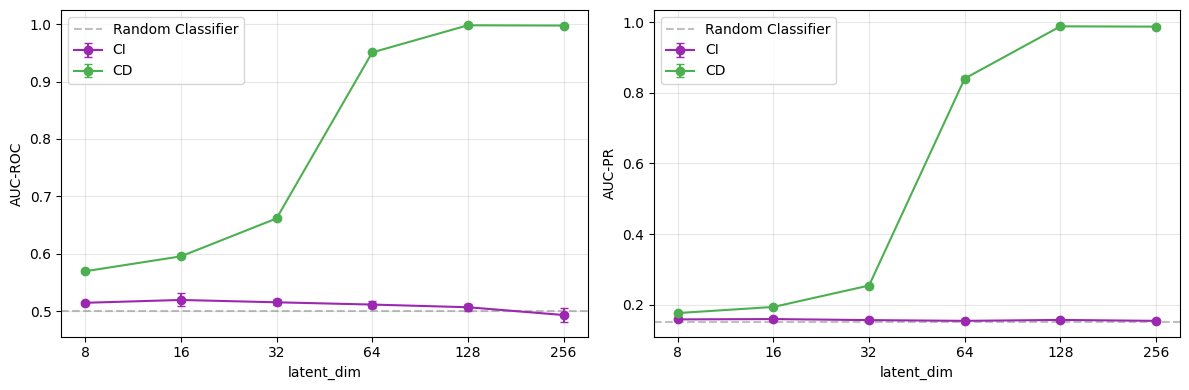

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key_ci, key_cd, ylabel in [
    (axes[0], "roc_ci", "roc_cd", "AUC-ROC"),
    (axes[1], "pr_ci",  "pr_cd",  "AUC-PR"),
]:
    ax.errorbar(final_results["latent_dim"], final_results[f"{key_ci}_mean"], yerr=final_results[f"{key_ci}_std"], fmt="o-", capsize=3, label="CI", color="#9C27B0")
    ax.errorbar(final_results["latent_dim"], final_results[f"{key_cd}_mean"], yerr=final_results[f"{key_cd}_std"], fmt="o-", capsize=3, label="CD", color="#4CAF50")
    ax.set_xscale("log", base=2)
    ax.set_xticks(latent_dims_sweep)
    ax.set_xticklabels(latent_dims_sweep)
    ax.set_xlabel("latent_dim")
    ax.set_ylabel(ylabel)
    ax.axhline(0.5 if "roc" in key_ci else test_labels.mean(), ls="--", color="gray", alpha=0.5, label="Random Classifier")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()